In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 55.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# ENVIRONMENT SETUP

In [3]:
# "Platform: https://www.kaggle.com/"
# "Accelerator: GPU T4 x2 (Dual GPU)"
# "Framework: PyTorch + Hugging Face Transformers + PEFT"
# "Dataset: Nougat Training Dataset Example:
# https://www.kaggle.com/datasets/zphilip/nougat-training-dataset-example"

import subprocess, sys

pkgs = [
    "transformers==4.45.0",
    "peft==0.12.0",
    "bitsandbytes>=0.46.1",
    "accelerate==0.34.2",
    "qwen-vl-utils",
    "gradio>=4.0.0",
    "datasets",
    "einops",
]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

print("All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 7.3 MB/s eta 0:00:00
All packages installed


# IMPORTS

In [4]:
import os, json, glob, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
from torch.utils.data import Dataset

from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
    TrainerCallback,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
    PeftModel,
)

from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
# qwen_vl_utils ships with the qwen-vl-utils package
from qwen_vl_utils import process_vision_info

warnings.filterwarnings("ignore")

#  GPU Check
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  |  {mem:.1f} GB")

2026-05-06 19:41:09.401574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778096469.619188      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778096469.686212      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778096470.213912      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778096470.213952      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778096470.213956      22 computation_placer.cc:177] computation placer alr

CUDA available : True
  GPU 0: Tesla T4  |  15.6 GB
  GPU 1: Tesla T4  |  15.6 GB


# CONFIGURATION

In [5]:
# All hyperparameters come directly from the manual's
# Have to use the MINIMUM value of every range as instructed.

CONFIG = {
    # -> Model
    # "2. Model Architecture"
    # "Use the pretrained Qwen2-VL-2B-Instruct"
    # "Model page: https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct"
    "model_name": "Qwen/Qwen2-VL-2B-Instruct",

    # -> Required Training Techniques (minimum values) 
    # "batch size: 1–2"            -> minimum: 1
    "batch_size":        1,
    # "gradient accumulation: 4–8" -> minimum: 4
    "grad_accumulation": 4,
    # "learning rate: 1e-4 to 2e-4" -> minimum: 1e-4
    "learning_rate":     1e-4,
    # "LoRA rank: 8 or 16"          -> minimum: 8
    "lora_rank":         8,
    # "image resolution: 512–768 px" -> minimum: 512 px
    "image_size":        512,
    # "2–5 epochs"                  -> minimum: 2
    "num_epochs":        2,

    # -> LoRA extra params ─
    "lora_alpha":        16,
    "lora_dropout":      0.05,

    # -> Dataset split ->
    # "Part 3: Dataset Subsetting"
    # "80% training"
    "train_ratio":       0.8,
    # "20% validation"
    "val_ratio":         0.2,

    # -> Paths ─
    "dataset_path":      "/kaggle/input/datasets/zphilip/nougat-training-dataset-example",
    "output_dir":        "/kaggle/working/qwen2vl_finetuned",
    "checkpoint_dir":    "/kaggle/working/checkpoints",

    # -> Checkpoint cadence 
    "save_every_n_epochs": 5,        

    # -> Generation ->
    "max_new_tokens":    1024,
    "max_seq_length":    2048,
    "seed":              42,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["checkpoint_dir"], "epoch_checkpoints"), exist_ok=True)

print("◤", "-" * 20, "◥")
print("CONFIGURATION SUMMARY")
print("◣", "_" * 20, "◢")
for k, v in CONFIG.items():
    print(f"  {k:<26}: {v}")

◤ -------------------- ◥
CONFIGURATION SUMMARY
◣ ____________________ ◢
  model_name                : Qwen/Qwen2-VL-2B-Instruct
  batch_size                : 1
  grad_accumulation         : 4
  learning_rate             : 0.0001
  lora_rank                 : 8
  image_size                : 512
  num_epochs                : 2
  lora_alpha                : 16
  lora_dropout              : 0.05
  train_ratio               : 0.8
  val_ratio                 : 0.2
  dataset_path              : /kaggle/input/datasets/zphilip/nougat-training-dataset-example
  output_dir                : /kaggle/working/qwen2vl_finetuned
  checkpoint_dir            : /kaggle/working/checkpoints
  save_every_n_epochs       : 5
  max_new_tokens            : 1024
  max_seq_length            : 2048
  seed                      : 42


# PART 1: DATASET EXPLORATION

In [6]:
# "1. Load the Nougat dataset"
# "2. Inspect image – markdown pairs"
# "3. Understand visual layout and document structure"
# "4. Select a subset of samples or full dataset for training"

print("◤", "-" * 20, "◥")
print("PART 1: DATASET EXPLORATION")
print("◣", "_" * 20, "◢")

#  "1. Load the Nougat dataset"
dataset_path = CONFIG["dataset_path"]
print(f"\n[1] Loading from: {dataset_path}")

# Walk tree (show first two levels)
for root, dirs, files in os.walk(dataset_path):
    depth  = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth < 2:
        sub = "  " * (depth + 1)
        for f in files[:6]:
            print(f"{sub}{f}")
        if len(files) > 6:
            print(f"{sub}... and {len(files)-6} more")

# Gather images
IMG_EXTS = ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]
image_files = []
for ext in IMG_EXTS:
    image_files.extend(glob.glob(os.path.join(dataset_path, "**", ext), recursive=True))
image_files = sorted(image_files)

# Gather markdown/mmd
MD_EXTS = ["*.mmd", "*.md", "*.txt"]
md_files = []
for ext in MD_EXTS:
    md_files.extend(glob.glob(os.path.join(dataset_path, "**", ext), recursive=True))
md_files = sorted(md_files)

print(f"\n[1] Image files found  : {len(image_files)}")
print(f"[1] Markdown files found: {len(md_files)}")

#  "2. Inspect image – markdown pairs"
def find_pairs(img_list, root):
    pairs = []
    for img_path in img_list:
        stem    = Path(img_path).stem
        img_dir = Path(img_path).parent
        search_dirs = [
            img_dir,
            img_dir.parent / "markdown",
            img_dir.parent / "mmd",
            img_dir.parent / "labels",
            img_dir.parent / "text",
            Path(root) / "markdown",
            Path(root) / "mmd",
        ]
        found = None
        for d in search_dirs:
            for ext in [".mmd", ".md", ".txt"]:
                cand = d / (stem + ext)
                if cand.exists():
                    found = str(cand)
                    break
            if found:
                break
        if found:
            try:
                content = Path(found).read_text(encoding="utf-8", errors="ignore").strip()
            except Exception:
                continue
            if content:
                pairs.append({"image_path": img_path,
                               "markdown_path": found,
                               "markdown": content})
    return pairs

# "2. Inspect image - markdown pairs"
all_pairs = find_pairs(image_files, dataset_path)
print(f"\n[2] Image–Markdown pairs found: {len(all_pairs)}")

#  "3. Understand visual layout and document structure"
if all_pairs:
    s   = all_pairs[0]
    img = Image.open(s["image_path"])
    print(f"\n[3] Sample inspection:")
    print(f"     Image path  : {s['image_path']}")
    print(f"     Image size  : {img.size}  mode={img.mode}")
    print(f"     MD path     : {s['markdown_path']}")
    print(f"     MD length   : {len(s['markdown'])} chars")
    print(f"     MD preview  :\n     {'-'*40}")
    for line in s["markdown"][:400].split("\n")[:12]:
        print(f"     {line}")
    print(f"     {'⁛'*40}")

    lengths = [len(p["markdown"]) for p in all_pairs]
    print(f"\n[3] Markdown statistics:")
    print(f"     total pairs : {len(all_pairs)}")
    print(f"     avg length  : {np.mean(lengths):.0f} chars")
    print(f"     min / max   : {np.min(lengths)} / {np.max(lengths)} chars")

#  "4. Select a subset of samples or full dataset for training"
# Using the full dataset if <= 500 samples, otherwise capping at 500 to fit within Kaggle T4×2 compute constraints.
MAX_SAMPLES = 500
if len(all_pairs) > MAX_SAMPLES:
    # "4. Select a subset of samples or full dataset for training"
    # -> subset selected to fit within Kaggle compute limits
    random.shuffle(all_pairs)
    all_pairs = all_pairs[:MAX_SAMPLES]
    print(f"\n[4] Subset selected: {len(all_pairs)} samples "
          f"(capped at {MAX_SAMPLES} for Kaggle T4×2 constraints)")
else:
    # "4. Select a subset of samples or full dataset for training"
    # -> using full dataset (fits within limits)
    print(f"\n[4] Using full dataset: {len(all_pairs)} samples")

print(f"\n Part 1 complete - {len(all_pairs)} samples ready")

◤ -------------------- ◥
PART 1: DATASET EXPLORATION
◣ ____________________ ◢

[1] Loading from: /kaggle/input/datasets/zphilip/nougat-training-dataset-example
nougat-training-dataset-example/
  0508.jsonl
  0508/
    astro-ph0508131/
    astro-ph0508089/
    math0508650/
    math-ph0508001/
    gr-qc0508101/
    nucl-th0508040/
    hep-th0508021/
    astro-ph0508602/
    hep-ex0508014/
    math0508511/
    nucl-ex0508014/
    cond-mat0508115/
    math0508205/
    math0508258/
    cond-mat0508204/
    astro-ph0508280/
    astro-ph0508340/
    cond-mat0508610/
    math0508140/
    cond-mat0508518/
    cs0508092/
    astro-ph0508338/
    hep-th0508136/
    math0508308/
    astro-ph0508069/
    astro-ph0508252/
    nucl-th0508033/
    astro-ph0508563/
    astro-ph0508604/
    cs0508017/
    quant-ph0508193/
    hep-ph0508293/
    cond-mat0508621/
    cond-mat0508338/
    quant-ph0508055/
    hep-ph0508053/
    cond-mat0508751/
    hep-th0508173/
    hep-th0508101/
    astro-ph0508101/
   

# PART 2: DATA PREPARATION - ChatML FORMAT

In [7]:
# "Convert the dataset into ChatML format. Each sample should contain:"
# "1. Image"
# "2. Instruction prompt"
# "3. Markdown target"

print("◤", "-" * 20, "◥")
print("PART 2: DATA PREPARATION  (ChatML Format)")
print("◣", "_" * 20, "◢")

# Instruction used for every sample
# "2. Instruction prompt"
INSTRUCTION_PROMPT = (
    "You are a document analysis expert. "
    "Convert the provided document image into well-structured Markdown documentation. "
    "Preserve all headings, lists, tables, equations, and formatting exactly as they appear."
)

def build_chatml_sample(raw):
    return {
        "image_path":   raw["image_path"],   # "1. Image"
        "instruction":  INSTRUCTION_PROMPT,  # "2. Instruction prompt"
        "markdown":     raw["markdown"],     # "3. Markdown target"
    }

chatml_samples = [build_chatml_sample(p) for p in all_pairs]

print(f"Converted {len(chatml_samples)} samples to ChatML format")
print(f"\nSample entry preview:")
s = chatml_samples[0]
print(f"  image_path   : {s['image_path']}")
print(f"  instruction  : {s['instruction'][:70]}...")
print(f"  markdown     : {s['markdown'][:80]}...")
print(f"\n Part 2 complete")

◤ -------------------- ◥
PART 2: DATA PREPARATION  (ChatML Format)
◣ ____________________ ◢
Converted 500 samples to ChatML format

Sample entry preview:
  image_path   : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/math-ph0508041/11.png
  instruction  : You are a document analysis expert. Convert the provided document imag...
  markdown     : ## References

* [1] X Bekaert and N Boulanger. Mixed symmetry gauge fields in a...

 Part 2 complete


# PART 3: DATASET SUBSETTING

In [8]:
# "Recommended split:"
# "80% training"
# "20% validation"

print("◤", "-" * 20, "◥")
print("PART 3: DATASET SUBSETTING")
print("◣", "_" * 20, "◢")

random.shuffle(chatml_samples)
total     = len(chatml_samples)
train_end = int(total * CONFIG["train_ratio"])  # "80% training"

# "80% training"
train_samples = chatml_samples[:train_end]
# "20% validation"
val_samples   = chatml_samples[train_end:]

print(f"Total   : {total}")
print(f"Train   : {len(train_samples):4d}  ({CONFIG['train_ratio']*100:.0f}%)  ← '80% training'")
print(f"Val     : {len(val_samples):4d}  ({CONFIG['val_ratio']*100:.0f}%)   ← '20% validation'")
print(f"\n Part 3 complete - 80 / 20 split applied")

◤ -------------------- ◥
PART 3: DATASET SUBSETTING
◣ ____________________ ◢
Total   : 500
Train   :  400  (80%)  ← '80% training'
Val     :  100  (20%)   ← '20% validation'

 Part 3 complete - 80 / 20 split applied


# PART 4: QLoRA SETUP  (Model + Quantization + LoRA)

In [9]:
# "3. Fine-Tuning Technique"
# "QLoRA (Quantized Low-Rank Adaptation)"
# "load the base model in 4-bit quantized form"
# "Freeze original pretrained weights"
# "Train only lightweight LoRA adapters"

print("◤", "-" * 20, "◥")
print("PART 4: MODEL LOADING + QLoRA SETUP")
print("◣", "_" * 20, "◢")

#  Step 1: Processor
# "Use the pretrained Qwen2-VL-2B-Instruct"
print("\n[1] Loading processor...")
processor = AutoProcessor.from_pretrained(
    CONFIG["model_name"],
    trust_remote_code=True,
    # Keep pixel count in range for 512-px images
    min_pixels=256 * 28 * 28,
    max_pixels=CONFIG["image_size"] * 28 * 28,   # "image resolution: 512–768 px" -> 512
)
print(f"    Processor ready: {CONFIG['model_name']}")

#  Step 2: 4-bit Quantization Config
# "load the base model in 4-bit quantized form"
# "4-bit quantization"
print("\n[2] Configuring 4-bit quantization (BitsAndBytes NF4)...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                          # "load the base model in 4-bit quantized form"
    bnb_4bit_quant_type="nf4",                  # NormalFloat4 - best for LLM weights
    bnb_4bit_compute_dtype=torch.bfloat16,      # Compute in bfloat16
    bnb_4bit_use_double_quant=True,             # Double quant -> extra memory savings
)
print("BNB config: 4-bit NF4, bfloat16 compute, double-quant")

#  Step 3: Load Base Model
# "Use the pretrained Qwen2-VL-2B-Instruct"
# "load the base model in 4-bit quantized form"
print(f"\n[3] Loading base model: {CONFIG['model_name']}")
print("(this takes a few minutes)...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    CONFIG["model_name"],
    quantization_config=bnb_config,             # "load the base model in 4-bit quantized form"
    device_map="auto",                          # Auto-distribute across both T4 GPUs
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
print(f"Model loaded - device_map=auto  |  dtype=bfloat16")

# "Freeze original pretrained weights"
model = prepare_model_for_kbit_training(model)
print("Pretrained weights frozen  <- 'Freeze original pretrained weights'")

#  Step 4: LoRA Adapters -----------------
# "Train only lightweight LoRA adapters"
# "LoRA rank: 8 or 16"  -> using 8 (minimum)
print(f"\n[4] Attaching LoRA adapters (rank={CONFIG['lora_rank']})...")

TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",    # Attention projections
    "gate_proj", "up_proj", "down_proj",        # FFN projections
]

lora_cfg = LoraConfig(
    r=CONFIG["lora_rank"],                      # "LoRA rank: 8 or 16" -> 8
    lora_alpha=CONFIG["lora_alpha"],            # Scaling = alpha / rank
    target_modules=TARGET_MODULES,
    lora_dropout=CONFIG["lora_dropout"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# "Train only lightweight LoRA adapters"
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

print(f"LoRA rank: {CONFIG['lora_rank']}")   # "LoRA rank: 8 or 16"
print(f"LoRA alpha: {CONFIG['lora_alpha']}")
print(f"Target modules: {TARGET_MODULES}")
print("\n QLoRA setup complete")

◤ -------------------- ◥
PART 4: MODEL LOADING + QLoRA SETUP
◣ ____________________ ◢

[1] Loading processor...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model loaded - device_map=auto  |  dtype=bfloat16
Pretrained weights frozen  <- 'Freeze original pretrained weights'

[4] Attaching LoRA adapters (rank=8)...
trainable params: 9,232,384 || all params: 2,218,217,984 || trainable%: 0.4162
LoRA rank: 8
LoRA alpha: 16
Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

 QLoRA setup complete


# PART 4 (i): DATASET CLASS + DATA COLLATOR

In [10]:
# "Part 2: Data Preparation"
# "Convert the dataset into ChatML format. Each sample should contain:"
# "1. Image   2. Instruction prompt   3. Markdown target"

class NougatVLMDataset(Dataset):
    def __init__(self, samples, processor, image_size=512, max_length=2048):
        self.samples    = samples
        self.processor  = processor
        self.image_size = image_size        # "image resolution: 512–768 px" -> 512
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # Load + resize image
        # "image resolution: 512–768 px" -> 512
        image = Image.open(s["image_path"]).convert("RGB")
        image = image.resize((self.image_size, self.image_size), Image.LANCZOS)

        #  Build ChatML messages
        # "Convert the dataset into ChatML format"
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},          # "1. Image"
                    {"type": "text",  "text": s["instruction"]},# "2. Instruction prompt"
                ],
            }
        ]

        # Prompt-only text - used to compute mask boundary
        prompt_text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        # Full conversation (prompt + assistant Markdown response)
        full_messages = messages + [
            # "3. Markdown target"
            {"role": "assistant", "content": s["markdown"]}
        ]
        full_text = self.processor.apply_chat_template(
            full_messages, tokenize=False, add_generation_prompt=False
        )

        # Tokenize both
        img_inputs, _ = process_vision_info(messages)

        def tok(text):
            return self.processor(
                text=[text], images=img_inputs,
                return_tensors="pt", padding=False,
                truncation=True, max_length=self.max_length,
            )

        prompt_enc = tok(prompt_text)
        full_enc   = tok(full_text)

        prompt_len = prompt_enc["input_ids"].shape[1]
        input_ids  = full_enc["input_ids"][0]

        # Mask prompt tokens from loss - only Markdown tokens are supervised
        labels = input_ids.clone()
        labels[:prompt_len] = -100      # -100 = ignored by CrossEntropyLoss

        return {
            "input_ids":      input_ids,
            "attention_mask": full_enc["attention_mask"][0],
            "pixel_values":   full_enc["pixel_values"],
            "image_grid_thw": full_enc["image_grid_thw"],
            "labels":         labels,
        }


#  Data Collator
class VLMDataCollator:
    def __init__(self, processor):
        self.pad_id = processor.tokenizer.pad_token_id or 0

    def __call__(self, batch):
        max_len = max(item["input_ids"].shape[0] for item in batch)

        in_ids, att, labs, pv_list, thw_list = [], [], [], [], []
        for item in batch:
            L   = item["input_ids"].shape[0]
            pad = max_len - L
            in_ids.append(torch.cat([item["input_ids"],
                                     torch.full((pad,), self.pad_id, dtype=torch.long)]))
            att.append(torch.cat([item["attention_mask"],
                                  torch.zeros(pad, dtype=torch.long)]))
            labs.append(torch.cat([item["labels"],
                                   torch.full((pad,), -100, dtype=torch.long)]))
            pv_list.append(item["pixel_values"])
            thw_list.append(item["image_grid_thw"])

        return {
            "input_ids":      torch.stack(in_ids),
            "attention_mask": torch.stack(att),
            "labels":         torch.stack(labs),
            "pixel_values":   torch.cat(pv_list, dim=0),
            "image_grid_thw": torch.cat(thw_list, dim=0),
        }


#  Instantiate
train_dataset = NougatVLMDataset(
    train_samples, processor,
    image_size=CONFIG["image_size"],        # "image resolution: 512–768 px" -> 512
    max_length=CONFIG["max_seq_length"],
)
val_dataset = NougatVLMDataset(
    val_samples, processor,
    image_size=CONFIG["image_size"],
    max_length=CONFIG["max_seq_length"],
)
data_collator = VLMDataCollator(processor)

print(f"Train dataset : {len(train_dataset)} samples")
print(f"Val dataset   : {len(val_dataset)} samples")
print("Datasets and collator ready")

Train dataset : 400 samples
Val dataset   : 100 samples
Datasets and collator ready


# PART 4 (ii): CHECKPOINT CALLBACK

In [11]:
# Saves a .pt checkpoint every 5 epochs.
# Also saves a PEFT adapter directory for easy reload with from_pretrained.
# If training is interrupted, resume using the instructions in the final cell.

class EpochCheckpointCallback(TrainerCallback):
    def __init__(self, save_every_n_epochs, checkpoint_dir):
        self.n    = save_every_n_epochs     # Every 5 epochs
        self.cdir = checkpoint_dir

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        if epoch > 0 and epoch % self.n == 0:
            self._save(model, state, epoch)
        return control

    def _save(self, model, state, epoch):
        base_dir  = os.path.join(self.cdir, "epoch_checkpoints")
        os.makedirs(base_dir, exist_ok=True)

        #  .pt file  (LoRA state dict only)
        pt_path = os.path.join(base_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save(
            {
                "epoch":       epoch,
                "global_step": state.global_step,
                # Save only LoRA params - everything else stays frozen/quantized
                "lora_state":  {k: v.cpu() for k, v in model.state_dict().items()
                                if "lora_" in k},
                "train_loss":  (state.log_history[-1].get("loss")
                                if state.log_history else None),
            },
            pt_path,
        )
        print(f"\n .pt checkpoint saved -> {pt_path}")

        #  PEFT adapter directory
        adapter_dir = os.path.join(base_dir, f"adapter_epoch_{epoch}")
        model.save_pretrained(adapter_dir)
        print(f"   PEFT adapter saved   -> {adapter_dir}")

    def on_train_end(self, args, state, control, model=None, **kwargs):
        """Always persist the final model."""
        # Final .pt
        final_pt = os.path.join(self.cdir, "final_checkpoint.pt")
        torch.save(
            {
                "epoch":       int(state.epoch),
                "global_step": state.global_step,
                "lora_state":  {k: v.cpu() for k, v in model.state_dict().items()
                                if "lora_" in k},
            },
            final_pt,
        )
        print(f"\n   Final .pt checkpoint -> {final_pt}")

        # Final PEFT adapter + processor
        final_adapter = os.path.join(CONFIG["output_dir"], "final_adapter")
        model.save_pretrained(final_adapter)
        processor.save_pretrained(final_adapter)
        print(f"   Final adapter+proc   -> {final_adapter}")
        return control


print("EpochCheckpointCallback defined (saves .pt every 5 epochs)")

EpochCheckpointCallback defined (saves .pt every 5 epochs)


# PART 4 (iii): TRAINING

◤ -------------------- ◥
PART 4: TRAINING
◣ ____________________ ◢
Training configuration:
  epochs          : 2
  batch size      : 1
  grad accum      : 4
  learning rate   : 0.0001
  LoRA rank       : 8
  image size      : 512 px



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,0.469400,0.474781
2,0.471000,0.467204


Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}



   Final .pt checkpoint -> /kaggle/working/checkpoints/final_checkpoint.pt


Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


   Final adapter+proc   -> /kaggle/working/qwen2vl_finetuned/final_adapter

Training complete!
  train_runtime: 7307.5248
  train_samples_per_second: 0.1090
  train_steps_per_second: 0.0270
  total_flos: 12209722001369088.0000
  train_loss: 0.5232
  epoch: 2.0000


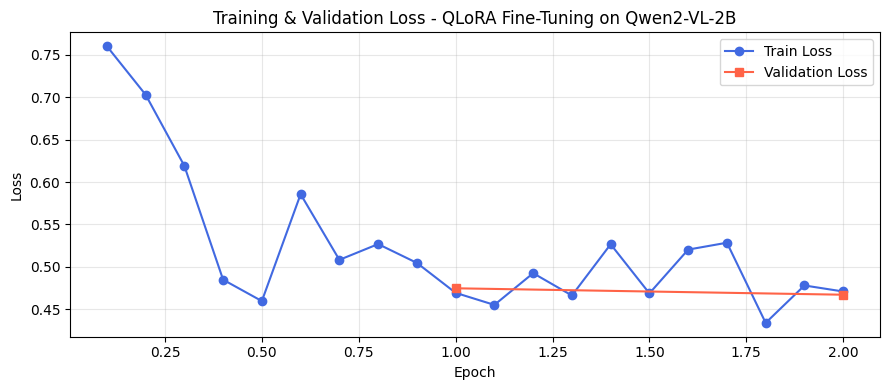

Loss curve saved -> /kaggle/working/qwen2vl_finetuned/loss_curve.png


In [12]:
# "Part 4: QLoRA Fine-Tuning"
# "Fine-tune the model using:"
# "4-bit quantization"  ← already applied
# "LoRA adapters"       ← already attached
# "2–5 epochs"          -> using 2

print("◤", "-" * 20, "◥")
print("PART 4: TRAINING")
print("◣", "_" * 20, "◢")

# "Required Training Techniques (to fit Kaggle T4×2)"
training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],

    # "2–5 epochs" -> 2
    num_train_epochs=CONFIG["num_epochs"],

    # "batch size: 1–2" -> 1
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=1,

    # "gradient accumulation: 4–8" -> 4
    gradient_accumulation_steps=CONFIG["grad_accumulation"],

    # "learning rate: 1e-4 to 2e-4" -> 1e-4
    learning_rate=CONFIG["learning_rate"],

    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",

    fp16=False,
    bf16=True,

    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    gradient_checkpointing=True,
    optim="paged_adamw_8bit",       # Memory-efficient optimizer designed for QLoRA
    dataloader_pin_memory=False,
    report_to="none",
    seed=CONFIG["seed"],
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[
        EpochCheckpointCallback(
            save_every_n_epochs=CONFIG["save_every_n_epochs"],  # Every 5 epochs
            checkpoint_dir=CONFIG["checkpoint_dir"],
        )
    ],
)

print("Training configuration:")
print(f"  epochs          : {CONFIG['num_epochs']}")        # "2–5 epochs"
print(f"  batch size      : {CONFIG['batch_size']}")        # "batch size: 1–2"
print(f"  grad accum      : {CONFIG['grad_accumulation']}") # "gradient accumulation: 4–8"
print(f"  learning rate   : {CONFIG['learning_rate']}")     # "learning rate: 1e-4 to 2e-4"
print(f"  LoRA rank       : {CONFIG['lora_rank']}")         # "LoRA rank: 8 or 16"
print(f"  image size      : {CONFIG['image_size']} px")     # "image resolution: 512–768 px"
print()

#  START TRAINING
train_result = trainer.train()

print("\nTraining complete!")
for k, v in train_result.metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

#  Plot loss curves
# "2. Fine Tuning Results -> Training loss / Validation loss"
history = trainer.state.log_history

train_pts = [(e["epoch"], e["loss"])      for e in history if "loss"      in e and "eval_loss" not in e]
val_pts   = [(e["epoch"], e["eval_loss"]) for e in history if "eval_loss" in e]

if train_pts:
    fig, ax = plt.subplots(figsize=(9, 4))
    if train_pts:
        ax.plot(*zip(*train_pts), marker="o", label="Train Loss",      color="royalblue")
    if val_pts:
        ax.plot(*zip(*val_pts),   marker="s", label="Validation Loss", color="tomato")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Training & Validation Loss - QLoRA Fine-Tuning on Qwen2-VL-2B")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    loss_path = os.path.join(CONFIG["output_dir"], "loss_curve.png")
    plt.savefig(loss_path, dpi=150)
    plt.show()
    print(f"Loss curve saved -> {loss_path}")

# PART 5: MARKDOWN GENERATION  (CORE TASK)

In [13]:
# "For each validation image:"
# "1. Run the fine-tuned model"
# "2. Generate Markdown output"
# "3. Compare with ground-truth"

print("◤", "-" * 20, "◥")
print("PART 5: MARKDOWN GENERATION (CORE TASK)")
print("◣", "_" * 20, "◢")

model.eval()

def generate_markdown(mdl, proc, image_path_or_pil, instruction=None,
                       image_size=512, max_new_tokens=512):
    instr = instruction or INSTRUCTION_PROMPT

    # Load / resize image
    if isinstance(image_path_or_pil, str):
        image = Image.open(image_path_or_pil).convert("RGB")
    else:
        image = image_path_or_pil.convert("RGB")
    # "image resolution: 512–768 px" -> 512
    image = image.resize((image_size, image_size), Image.LANCZOS)

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": instr},
        ]}
    ]
    prompt_text  = proc.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    img_inputs, _ = process_vision_info(messages)

    inputs = proc(
        text=[prompt_text], images=img_inputs,
        return_tensors="pt", padding=True,
    ).to(mdl.device)

    with torch.no_grad():
        gen_ids = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=proc.tokenizer.pad_token_id,
            eos_token_id=proc.tokenizer.eos_token_id,
        )

    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], gen_ids)]
    return proc.batch_decode(trimmed, skip_special_tokens=True,
                              clean_up_tokenization_spaces=False)[0].strip()


#  Run on validation samples
# "For each validation image:"
N_VAL = min(5, len(val_samples))
val_results = []

print(f"Generating Markdown for {N_VAL} validation images...")
for i, s in enumerate(val_samples[:N_VAL]):
    print(f"  [{i+1}/{N_VAL}] {Path(s['image_path']).name}")
    # "1. Run the fine-tuned model"
    # "2. Generate Markdown output"
    pred = generate_markdown(model, processor, s["image_path"],
                              image_size=CONFIG["image_size"],
                              max_new_tokens=CONFIG["max_new_tokens"])
    val_results.append({
        "label":        f"Val {i+1}",
        "image_path":   s["image_path"],
        "ground_truth": s["markdown"],   # "3. Compare with ground-truth"
        "predicted":    pred,
    })
    print(f"-> {len(pred)} chars generated")

print(f"\n Part 5 complete - {len(val_results)} validation samples processed")

◤ -------------------- ◥
PART 5: MARKDOWN GENERATION (CORE TASK)
◣ ____________________ ◢
Generating Markdown for 5 validation images...
  [1/5] 26.png
-> 617 chars generated
  [2/5] 09.png
-> 1035 chars generated
  [3/5] 15.png
-> 1283 chars generated
  [4/5] 02.png
-> 2615 chars generated
  [5/5] 06.png
-> 2623 chars generated

 Part 5 complete - 5 validation samples processed


# PART 6: TESTING TASK

In [14]:
# "Generate Markdown Outputs for:"
# "-> 3 training images"
# "-> 3 unseen document images"

print("◤", "-" * 20, "◥")
print("PART 6: TESTING TASK")
print("◣", "_" * 20, "◢")

#  A) 3 Training Images
print("\n[A] 3 TRAINING images:")
train_test = []
for i, s in enumerate(train_samples[:3]):   # "3 training images"
    print(f"  Train [{i+1}/3] {Path(s['image_path']).name}")
    pred = generate_markdown(model, processor, s["image_path"],
                              image_size=CONFIG["image_size"],
                              max_new_tokens=CONFIG["max_new_tokens"])
    train_test.append({
        "label":        f"Train Image {i+1}",
        "image_path":   s["image_path"],
        "ground_truth": s["markdown"],
        "predicted":    pred,
        "type":         "training",
    })
    print(f"     {len(pred)} chars")

#  B) 3 Unseen Document Images
print("\n[B] 3 UNSEEN document images:")
print("    Place your own images in /kaggle/working/test_images/")
print("    (PNG or JPG, not from the training/validation set)")
print("    If none found, synthetic pages will be generated automatically.\n")

unseen_dir = "/kaggle/working/test_images"
os.makedirs(unseen_dir, exist_ok=True)

unseen_paths = sorted(
    glob.glob(os.path.join(unseen_dir, "*.png")) +
    glob.glob(os.path.join(unseen_dir, "*.jpg"))
)

if len(unseen_paths) < 3:
    print("  [INFO] Fewer than 3 unseen images found - generating synthetic document pages...")
    for n in range(1, 4):
        content = (
            f"# Document {n}\n\n"
            f"## Abstract\nSynthetic test document #{n} for unseen-image evaluation.\n\n"
            f"## Section 1\nContent paragraph with **bold**, _italic_, and `inline code`.\n\n"
            f"- Bullet A\n- Bullet B\n- Bullet C\n\n"
            f"| Col 1 | Col 2 |\n|-------|-------|\n| A     | 1     |\n"
            f"\n## Equation\n$E = mc^2$\n"
        )
        fig, ax = plt.subplots(figsize=(5.12, 5.12), dpi=100)
        ax.axis("off")
        ax.text(0.03, 0.97, content, transform=ax.transAxes,
                fontsize=9, va="top", fontfamily="monospace",
                bbox=dict(boxstyle="square", fc="white", ec="none"))
        p = os.path.join(unseen_dir, f"unseen_{n}.png")
        plt.savefig(p, bbox_inches="tight", facecolor="white")
        plt.close()
        unseen_paths.append(p)
    print(f"  Created {len(unseen_paths)} synthetic images in {unseen_dir}")

unseen_test = []
for i, img_path in enumerate(unseen_paths[:3]):   # "3 unseen document images"
    print(f"  Unseen [{i+1}/3] {Path(img_path).name}")
    pred = generate_markdown(model, processor, img_path,
                              image_size=CONFIG["image_size"],
                              max_new_tokens=CONFIG["max_new_tokens"])
    unseen_test.append({
        "label":        f"Unseen Image {i+1}",
        "image_path":   img_path,
        "ground_truth": "(No ground truth - unseen document)",
        "predicted":    pred,
        "type":         "unseen",
    })
    print(f"     {len(pred)} chars")

all_test_results = train_test + unseen_test
print(f"\n Part 6 complete - 3 training + 3 unseen images tested")

◤ -------------------- ◥
PART 6: TESTING TASK
◣ ____________________ ◢

[A] 3 TRAINING images:
  Train [1/3] 10.png
     3115 chars
  Train [2/3] 05.png
     3106 chars
  Train [3/3] 14.png
     1950 chars

[B] 3 UNSEEN document images:
    Place your own images in /kaggle/working/test_images/
    (PNG or JPG, not from the training/validation set)
    If none found, synthetic pages will be generated automatically.

  [INFO] Fewer than 3 unseen images found - generating synthetic document pages...
  Created 3 synthetic images in /kaggle/working/test_images
  Unseen [1/3] unseen_1.png
     4024 chars
  Unseen [2/3] unseen_2.png
     2196 chars
  Unseen [3/3] unseen_3.png
     1352 chars

 Part 6 complete - 3 training + 3 unseen images tested


# 5. VISUALIZATION MODULE

◤ -------------------- ◥
VISUALIZATION MODULE
◣ ____________________ ◢

--- Validation Predictions ---


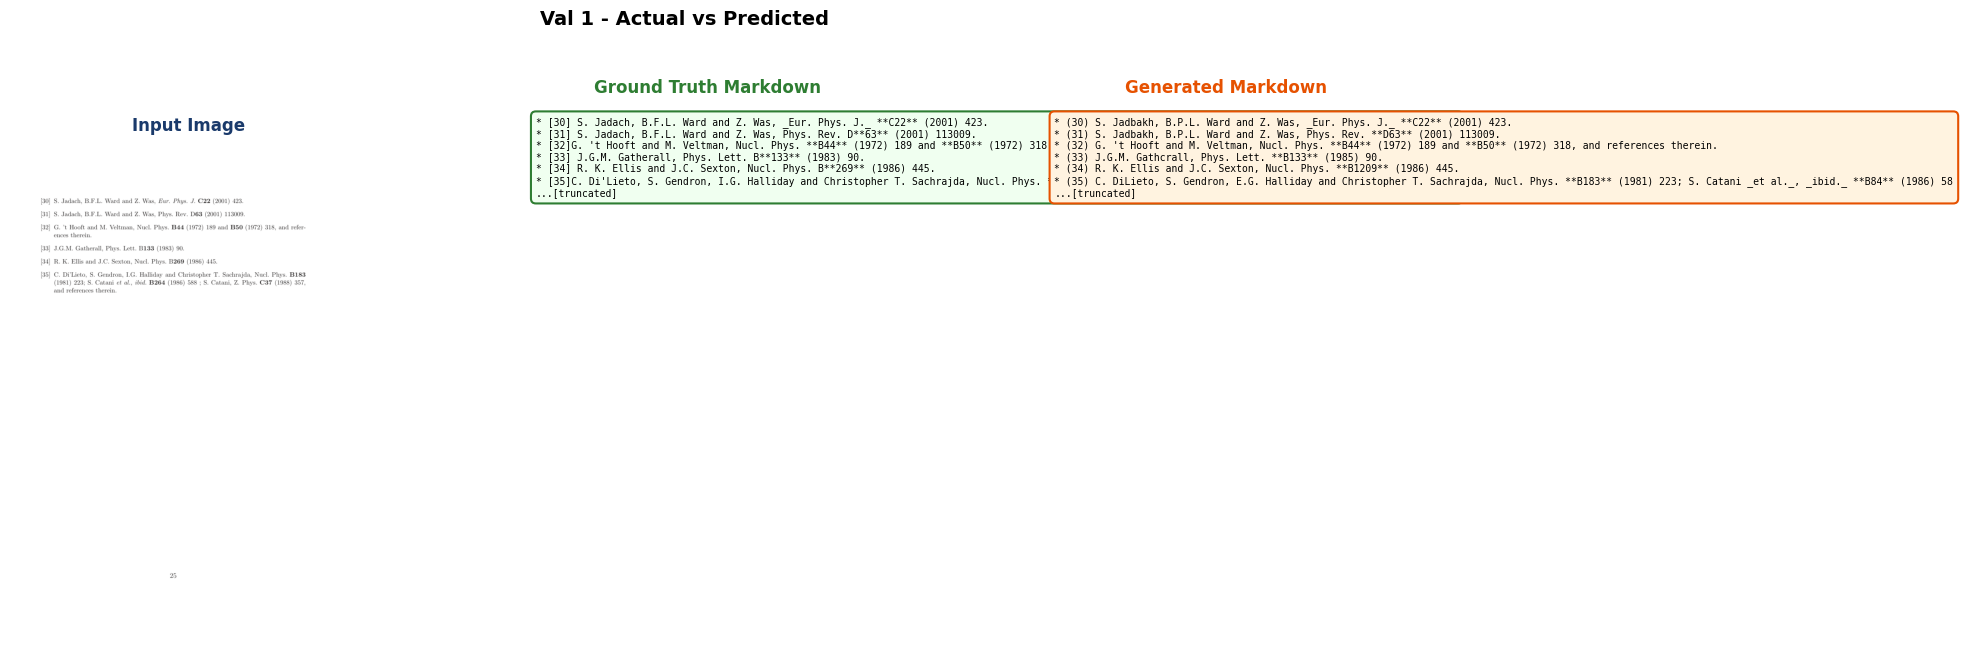

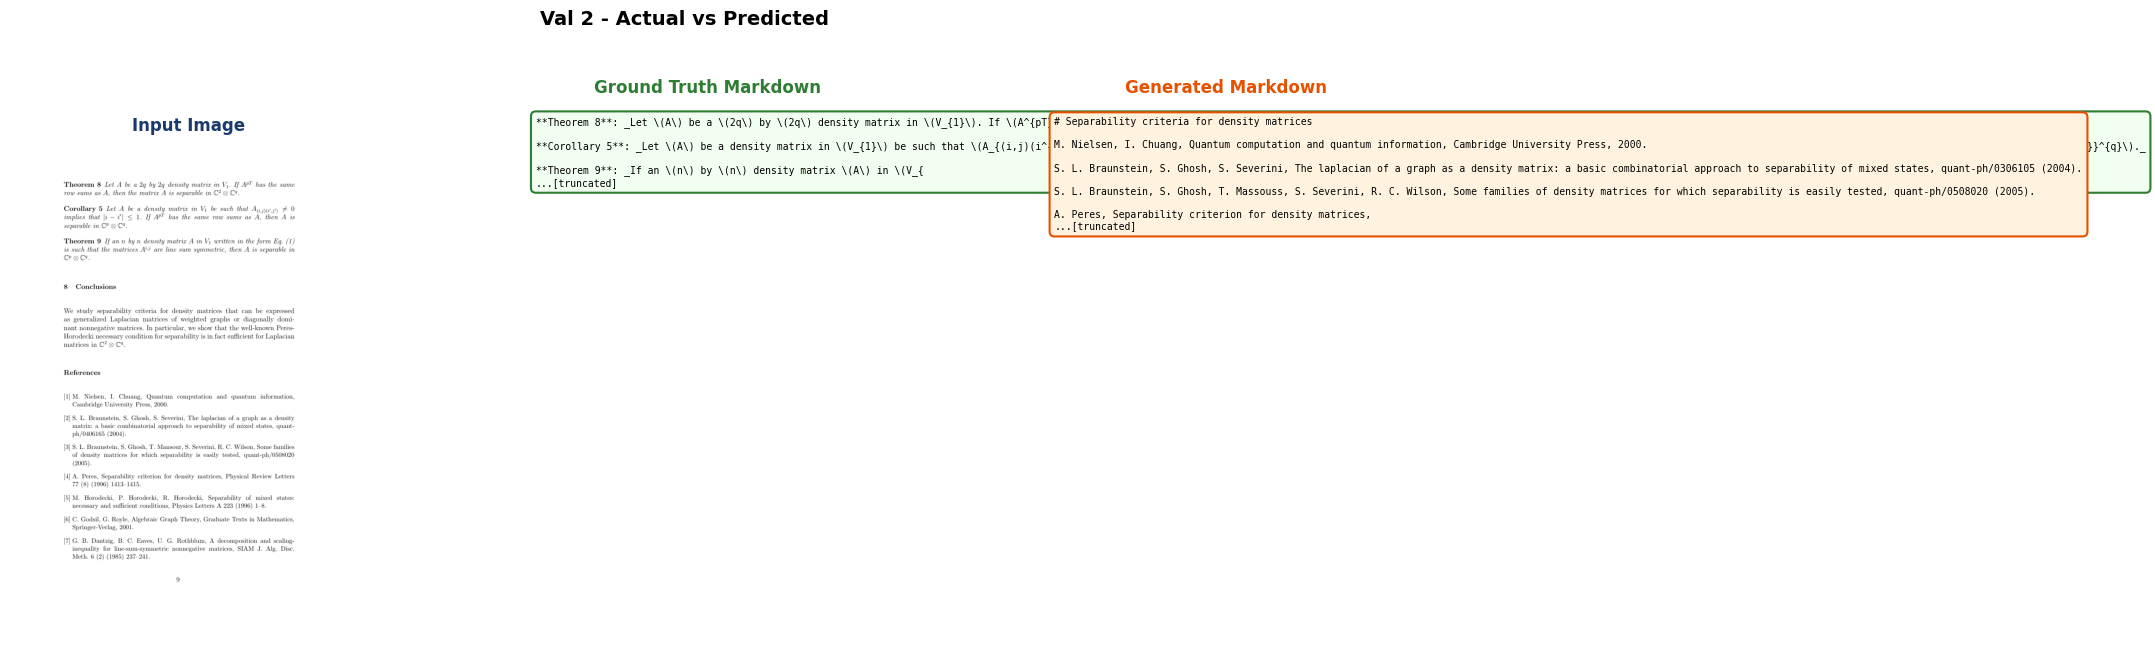

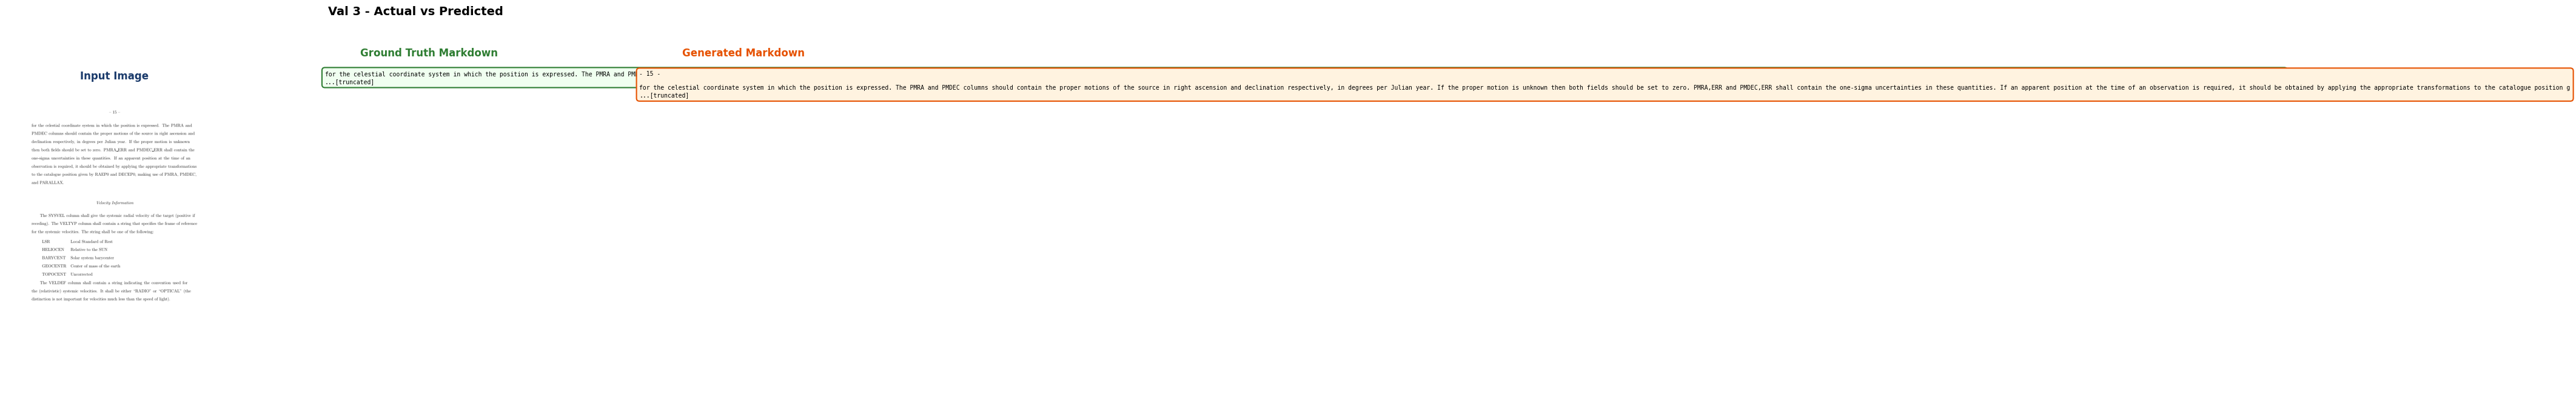


--- Test: Training Images ---


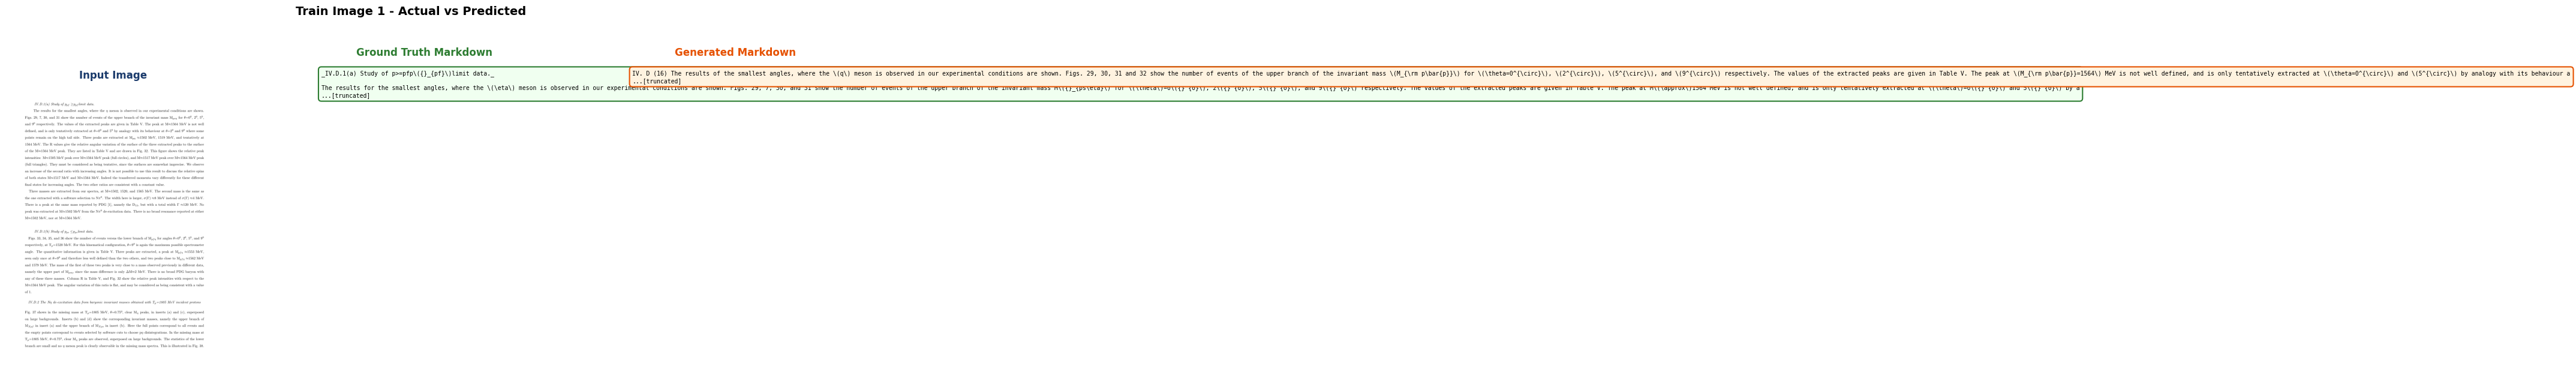

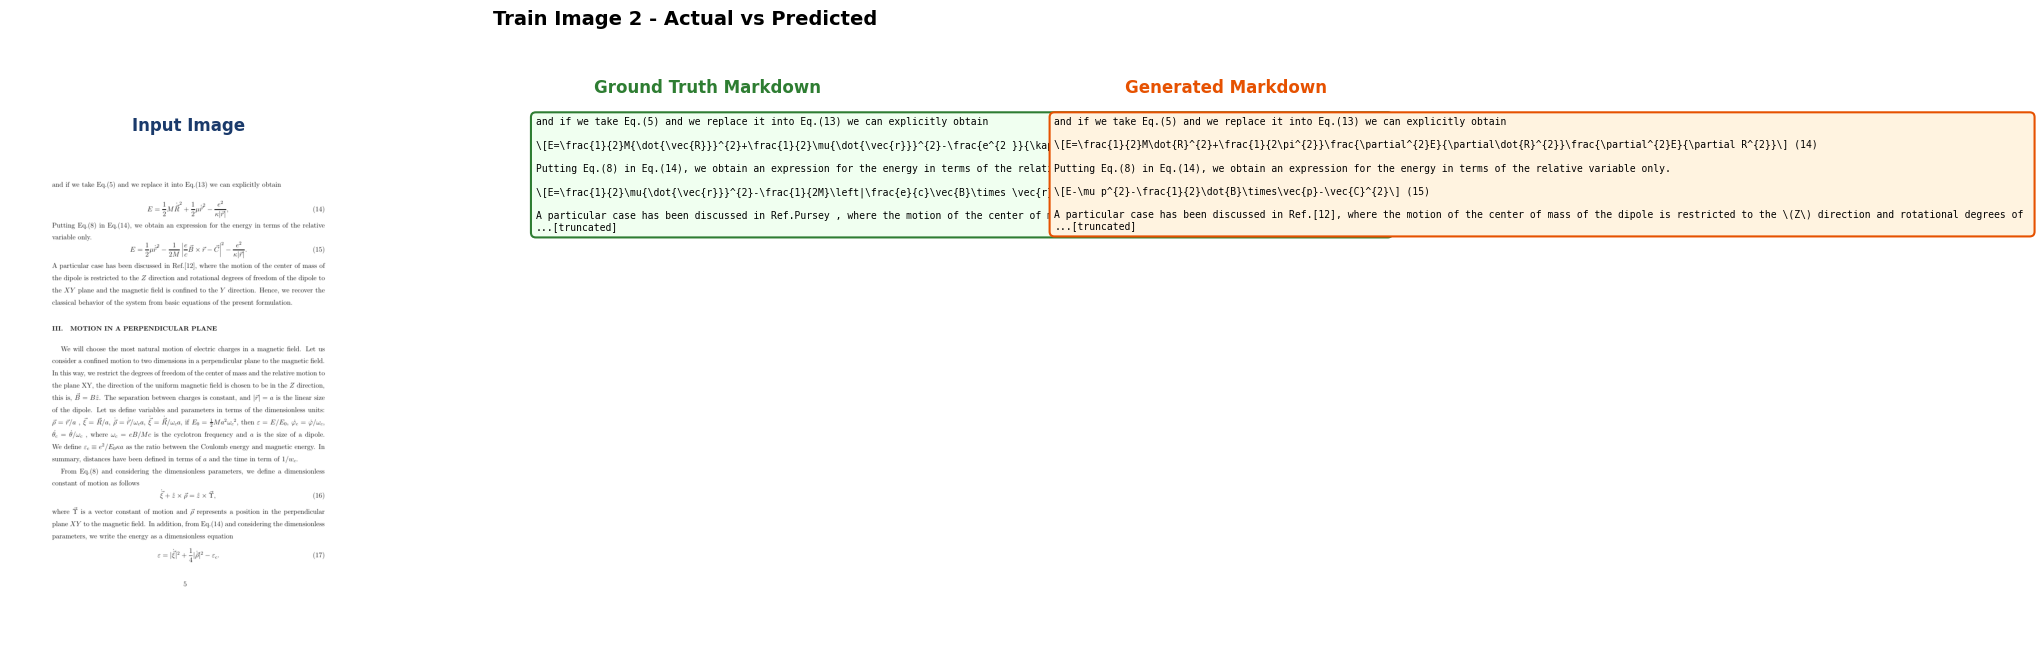

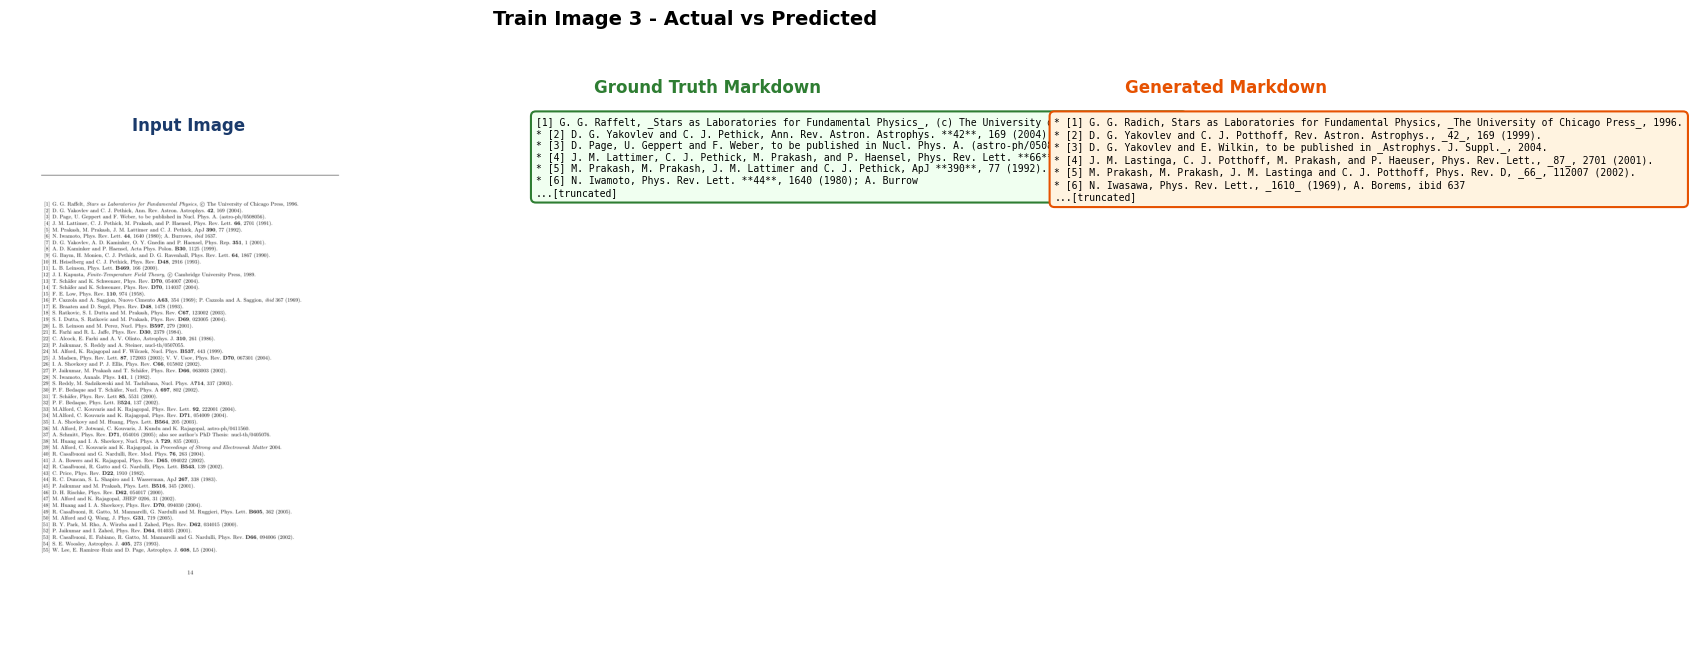


--- Test: Unseen Images ---


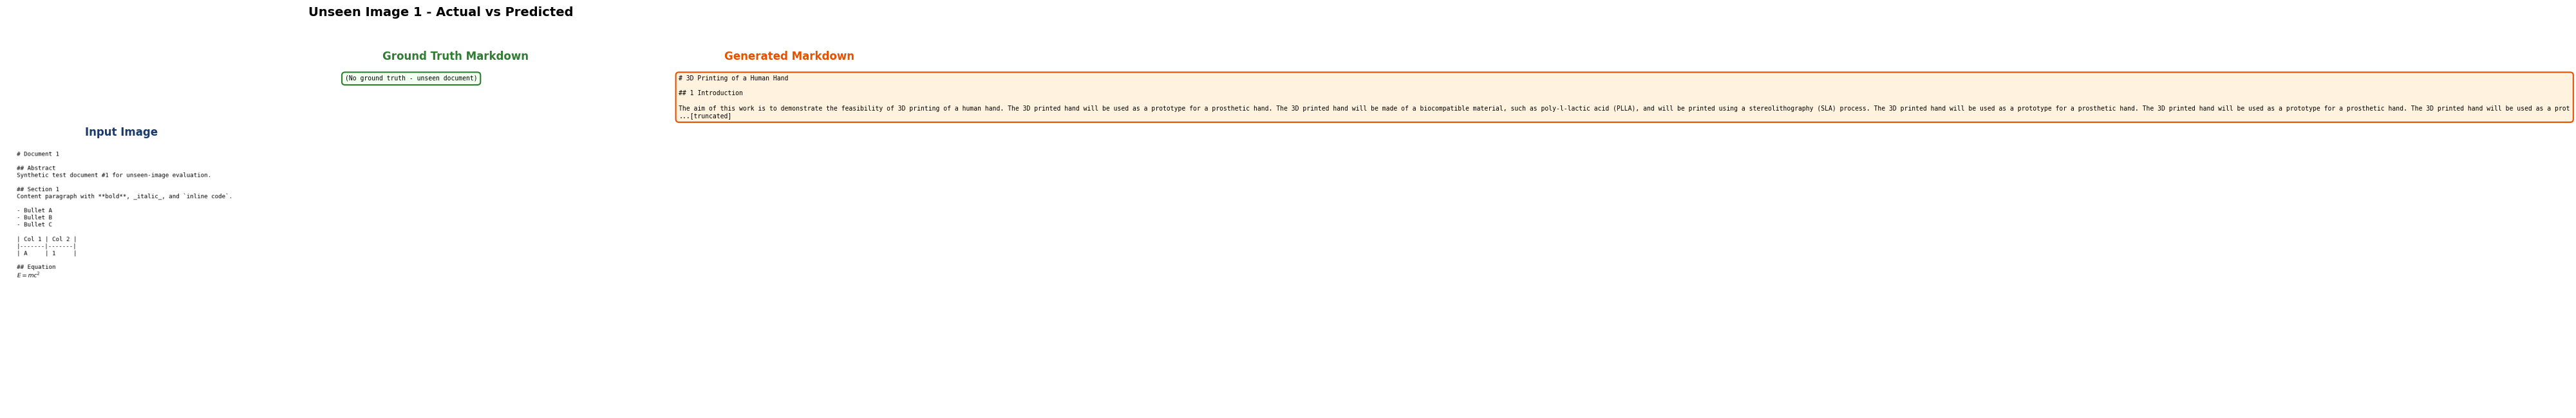

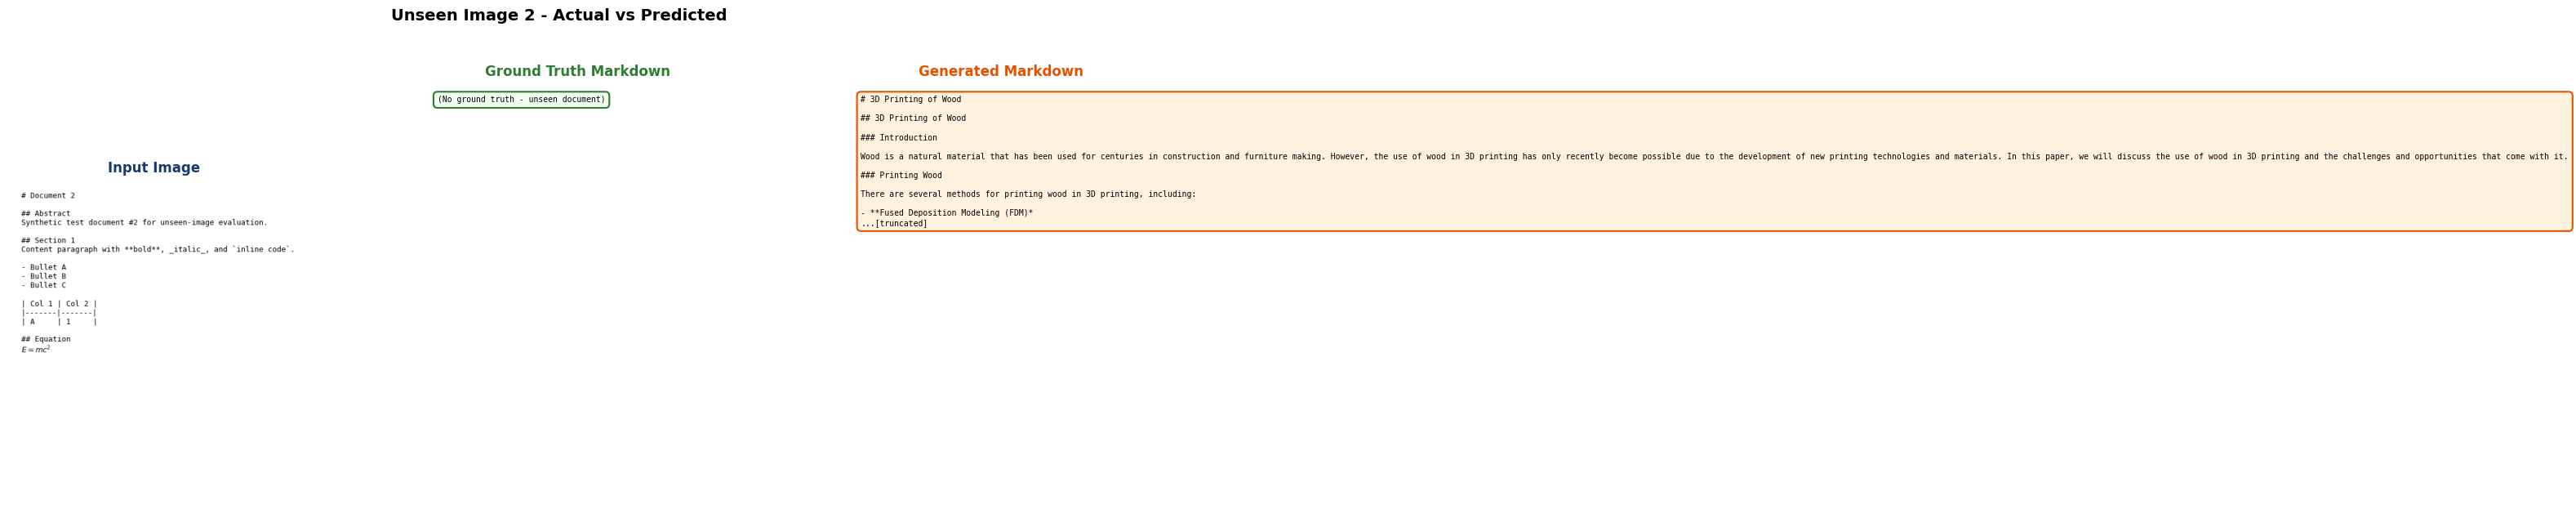

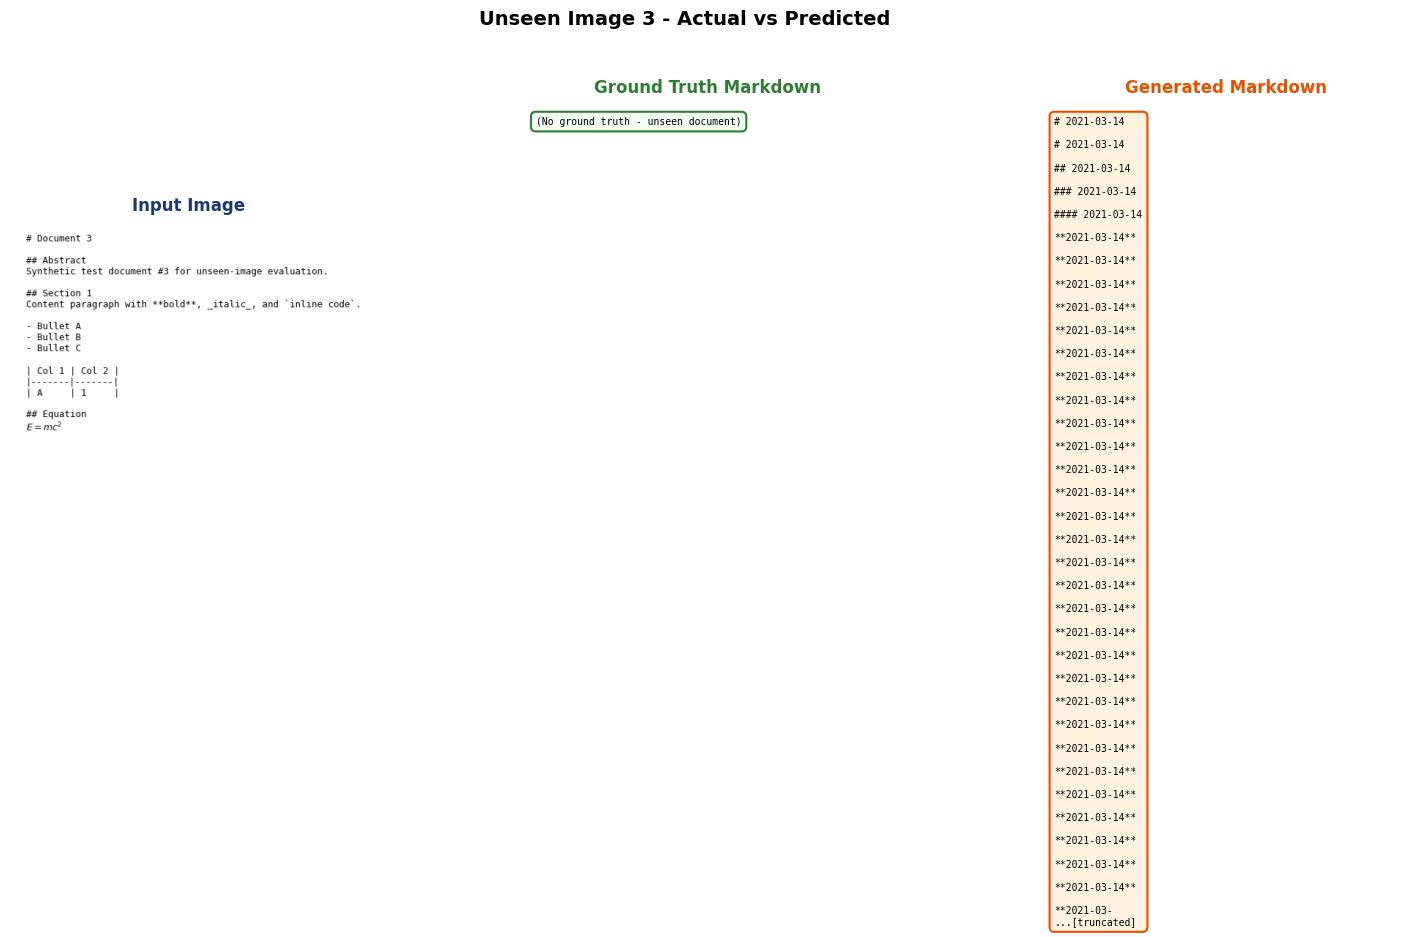


 All visualizations saved to /kaggle/working/qwen2vl_finetuned


In [15]:
# "Display:"
# "-> Input image"
# "-> Ground truth markdown"
# "-> Generated markdown"
# "Deliverables -> 3. Screenshots -> Output predictions / Visualization results"
# "Deliverables -> 2. Fine Tuning Results -> Comparison (Actual vs Predicted)"

print("◤", "-" * 20, "◥")
print("VISUALIZATION MODULE")
print("◣", "_" * 20, "◢")

def visualize(result, save_path=None, figsize=(18, 7)):
    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(1, 3, wspace=0.45)

    #  Panel 1: Input Image
    ax1 = fig.add_subplot(gs[0])
    img = Image.open(result["image_path"]).convert("RGB")
    ax1.imshow(img)
    ax1.set_title("Input Image", fontsize=12, fontweight="bold", color="#1a3a6b")
    ax1.axis("off")

    #  Panel 2: Ground Truth Markdown
    ax2 = fig.add_subplot(gs[1])
    ax2.axis("off")
    gt_preview = result["ground_truth"][:550] + (
        "\n...[truncated]" if len(result["ground_truth"]) > 550 else "")
    ax2.text(0.02, 0.97, gt_preview, transform=ax2.transAxes,
             fontsize=7, va="top", fontfamily="monospace",
             bbox=dict(boxstyle="round,pad=0.5", fc="#f0fff0", ec="#2e7d32", lw=1.5))
    ax2.set_title("Ground Truth Markdown", fontsize=12, fontweight="bold", color="#2e7d32")

    #  Panel 3: Generated Markdown
    ax3 = fig.add_subplot(gs[2])
    ax3.axis("off")
    pred_preview = result["predicted"][:550] + (
        "\n...[truncated]" if len(result["predicted"]) > 550 else "")
    ax3.text(0.02, 0.97, pred_preview, transform=ax3.transAxes,
             fontsize=7, va="top", fontfamily="monospace",
             bbox=dict(boxstyle="round,pad=0.5", fc="#fff3e0", ec="#e65100", lw=1.5))
    ax3.set_title("Generated Markdown", fontsize=12, fontweight="bold", color="#e65100")

    # "Comparison (Actual vs Predicted)"
    fig.suptitle(f"{result.get('label','Sample')} - Actual vs Predicted",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()


#  Visualize validation results
print("\n--- Validation Predictions ---")
for r in val_results[:3]:
    sp = os.path.join(CONFIG["output_dir"], f"viz_{r['label'].replace(' ','_')}.png")
    visualize(r, save_path=sp)

#  Visualize test results (Part 6)
print("\n--- Test: Training Images ---")
for r in train_test:
    sp = os.path.join(CONFIG["output_dir"], f"viz_{r['label'].replace(' ','_')}.png")
    visualize(r, save_path=sp)

print("\n--- Test: Unseen Images ---")
for r in unseen_test:
    sp = os.path.join(CONFIG["output_dir"], f"viz_{r['label'].replace(' ','_')}.png")
    visualize(r, save_path=sp)

print(f"\n All visualizations saved to {CONFIG['output_dir']}")

In [16]:
# =============================================================================
# APP DEPLOYMENT - GRADIO (local preview inside Kaggle)
# "4. App Deployment:"
# "Build a Gradio or Streamlit App that should:"
# "▪ Upload image"
# "▪ Generate Markdown"
#
# NOTE: The Kaggle share=True link is temporary.
# For PERMANENT deployment, follow the Hugging Face Spaces instructions
# in the final Markdown cell below.
# =============================================================================

import gradio as gr

# Use the model already in memory
_infer_model = model
_infer_proc  = processor

def gradio_predict(image, custom_instruction):
    """
    "4. App Deployment"
    "▪ Upload image"  ->  image input
    "▪ Generate Markdown"  ->  Markdown text output
    """
    if image is None:
        return "⚠️  Please upload a document image."

    instr = (custom_instruction.strip()
             if custom_instruction and custom_instruction.strip()
             else INSTRUCTION_PROMPT)

    result = generate_markdown(
        _infer_model, _infer_proc, image,
        instruction=instr,
        image_size=CONFIG["image_size"],       # "image resolution: 512–768 px" -> 512
        max_new_tokens=CONFIG["max_new_tokens"],
    )
    return result


#  Build Gradio App -------------------─
# "4. App Deployment:"
# "Build a Gradio or Streamlit App that should:"
with gr.Blocks(title="Document -> Markdown | QLoRA Qwen2-VL", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 📄 Document -> Markdown Generator
        **Fine-tuned Qwen2-VL-2B-Instruct** with QLoRA on the Nougat dataset.
        Upload any document image and receive structured Markdown output instantly.
        """
    )
    with gr.Row():
        with gr.Column(scale=1):
            # "▪ Upload image"
            img_in   = gr.Image(type="pil", label="📷 Upload Document Image", height=380)
            instr_in = gr.Textbox(
                label="Custom Instruction (optional - leave blank for default)",
                placeholder="e.g. Convert this slide to Markdown with all bullet points.",
                lines=2,
            )
            btn = gr.Button("🔄 Generate Markdown", variant="primary", size="lg")
        with gr.Column(scale=1):
            # "▪ Generate Markdown"
            md_out      = gr.Textbox(label="📝 Generated Markdown",
                                     lines=22, show_copy_button=True)
            md_rendered = gr.Markdown(label="👁  Rendered Preview")

    btn.click(fn=gradio_predict, inputs=[img_in, instr_in], outputs=[md_out])
    md_out.change(fn=lambda x: x, inputs=md_out, outputs=md_rendered)

    # Example inputs from the validation set
    gr.Examples(
        examples=[[s["image_path"], ""] for s in val_samples[:3]],
        inputs=[img_in, instr_in],
        label="Example inputs from the validation set",
    )

# Launch with share=True for a temporary Kaggle public URL
# For a permanent URL, see the deployment guide in the next cell.
demo.launch(share=True, debug=False, quiet=True)
print("\n Gradio app is live - see the public URL above")
print("(This URL is temporary. For permanent hosting, see the next cell.)")

* Running on public URL: https://8aed2e8e87a9c5e1fc.gradio.live



 Gradio app is live - see the public URL above
(This URL is temporary. For permanent hosting, see the next cell.)
